# Roman Slitless Spectroscopy Data Challenge
### 1D extraction from four-roll grism simulations

**Roman WFI · one chip (SCA 5) · COSMOS field · 1.00–1.93 μm**

* Preserter: Mainak Singha

*Dispersion solution and simulations: Isak Wold*

---

Roman's grism has no slit. Every object in the field disperses at once, each
spectrum an ~880-pixel streak — about 21% of the detector axis — and with 500
catalogued sources on one chip, overlaps are the norm, not the exception. The
same field is therefore observed at four roll angles: same sky, four dispersion
directions. A neighbour that lands on your spectrum at one roll misses it at
another. The rolls are the decontamination tool.

This notebook is the live demo: locate a trace, register it onto the data,
handle the background, extract and flux-calibrate a 1D spectrum, then see
contamination in the images and combine the four rolls to remove it. Your
challenge task is defined at the end.

## The dataset

| File | What it is |
|---|---|
| 4 grism frames (`noisy_grism_SCA5_..._PA_{0,150,182,214}_...fits`) | 4088×4088, e⁻/s, 380 s exposures, 0.8 e⁻/s zodiacal background, Poisson + read noise |
| 4 direct images (F125W, one per PA) | source positions and the WCS reference |
| `detectors.pickle` | sky → detector: 22-coefficient dispersion solution, wrapped in `geometry.py` |
| `catalog_radec.txt` | 500 sources at 5σ, brightest first — a detection catalogue, **not** complete to the frame depth |
| `grism_11_espresso.txt` | the throughput table the simulation used (wavelength, A_eff) |
| `WFI_focal_plane_persistence_response.png` | WFI focal-plane figure (Roman project webpage), shown below for orientation |

Pointing centre = CRVAL = (150.1271594, 2.3351436), pixel scale 0.11″/px. All
four rolls share one pointing centre; only the sky rotation differs.

**The dispersion model.** For a source at (RA, Dec) and a wavelength,
`GrismGeometry.trace(ra, dec, lam)` returns the detector pixel where that light
lands. Dispersion ~1.05 nm/px, running along +y at 88–90° from +x; the tilt
varies with position, so each trace is handled with its own local angle.
Resolving power R = 461·λ[μm] for a point source.

**The four lines that do all the work** — everything else in this notebook is
detail around them:

```
geom  = GrismGeometry('detectors.pickle', 'SCA#5', CENTRE, theta=PA)
tr    = correct_offset(pa, ra, dec)            # prediction, moved onto the data
strip, offs = trace_strip(frame, tr)           # straighten: lambda across, offset down
flux, err   = extract_optimal(strip - bkg, offs, var)   # collapse to 1D
```

Repeat per roll, flag wavelengths where a neighbour's trace overlaps, combine
using the clean rolls. That is the whole pipeline.

In [33]:
# Load. Nothing is computed yet.
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import map_coordinates

from geometry import GrismGeometry, SCA_SIZE

SLICE_CENTER = (150.1271594365, 2.335143637986)   # field center (RA, Dec) [deg]
ROLLS = [0, 150, 182, 214]                        # the four roll angles
GRISM = "noisy_grism_SCA5_0.030_00_1_22_1_r_1_b_1_PA_{pa}_dx_0.0.fits"

geom = {pa: GrismGeometry("detectors.pickle", "SCA#5", SLICE_CENTER, theta=pa)
        for pa in ROLLS}
frames = {pa: fits.open(GRISM.format(pa=pa), memmap=True)[0].data
          for pa in ROLLS}                        # memmap: pixels read on demand
cat = np.loadtxt("catalog_radec.txt", usecols=(0, 1), ndmin=2)
lam = np.arange(1.00, 1.93, 0.001)                # 10 A per column, ~930 columns

T_EFF = 380.0                                     # exposure time [s]
print(len(cat), "sources; frames:", {pa: frames[pa].shape for pa in ROLLS})

500 sources; frames: {0: (4088, 4088), 150: (4088, 4088), 182: (4088, 4088), 214: (4088, 4088)}


## What we are looking at

Each frame is one Roman Wide Field Instrument detector — a 4088 x 4088
"Sensor Chip Assembly" (SCA). The WFI focal plane has 18 of them; our data is
SCA 5 only. Left: where SCA 5 sits among the 18 detectors of the WFI focal plane. Right: the
actual PA 0 grism frame. Every diagonal streak is one object's spectrum,
dispersed by the grism — there is no "image" of the field here, only spectra.

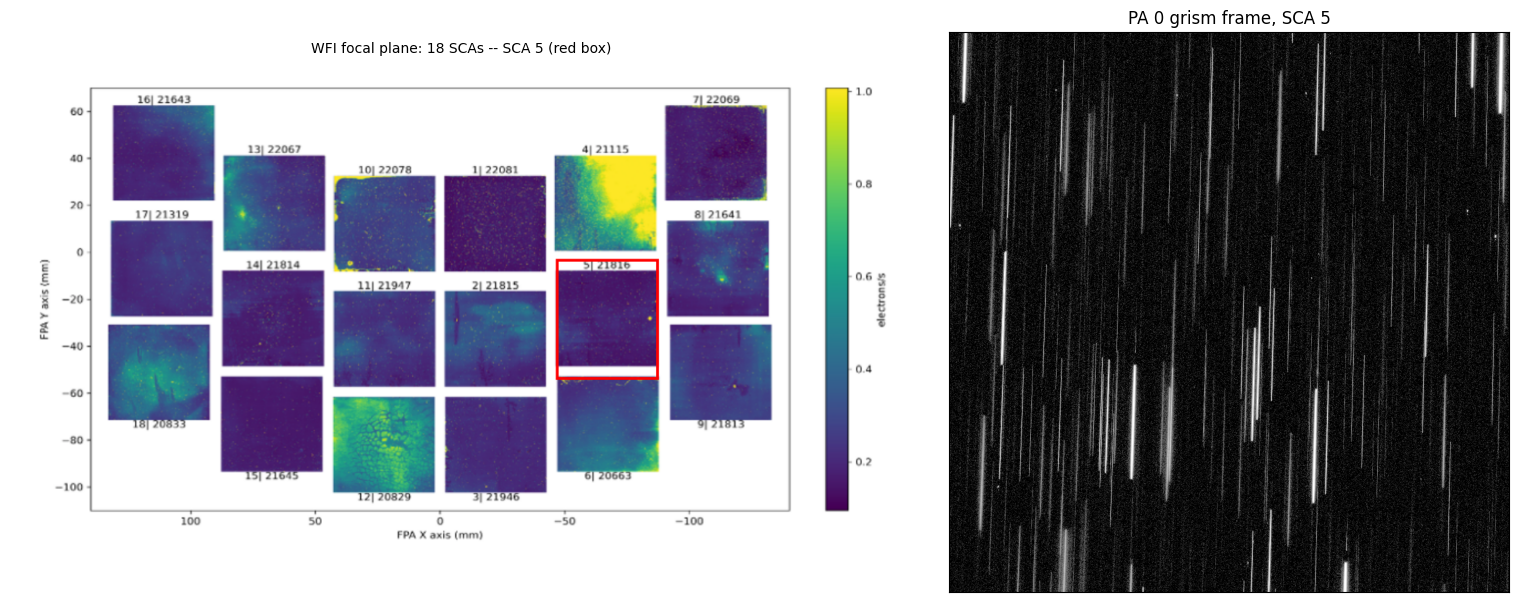

In [47]:
# Left: the WFI focal plane; SCA 5 boxed in red. Right: our PA 0 grism frame.
import matplotlib.image as mpimg

FP_FILE = "SCA5.png"

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15.5, 6),
                               gridspec_kw={"width_ratios": [1.5, 1]})

axL.imshow(mpimg.imread(FP_FILE))
axL.set_title("WFI focal plane: 18 SCAs -- SCA 5 (red box)", fontsize=10)
axL.axis("off")

d = np.asarray(frames[0][::4, ::4], float)
med = np.median(d); mad = 1.4826*np.median(np.abs(d - med))
axR.imshow(np.arcsinh((d - med)/mad), origin="lower", cmap="gray",
           vmin=0, vmax=np.arcsinh(50))
axR.set_title("PA 0 grism frame, SCA 5")
axR.set_xticks([]); axR.set_yticks([])
plt.tight_layout(); plt.show()

## Where should each spectrum be?

The optical model (`detectors.pickle` + `geometry.py`) maps
(RA, Dec, wavelength) to a detector pixel — for every object we can predict
the line its spectrum should trace. Below: the prediction drawn over the data
for one bright source. The tilt and length match, which validates the
dispersion solution. But the line sits a few pixels to the side of the flux.

That sideways miss comes from the source *positions*, not the optics: our
coordinates are direct-image centroids, and for blended or extended objects
the centroid can sit pixels away from the position the simulator actually
dispersed. The registration diagnostics at the end of this notebook show the
per-source scatter (~2-2.5 px) is as large as the per-roll medians, so this is
a per-source effect — one global shift would not fix it. The cure is standard
slitless practice (aXe, grizli): measure each trace's offset from the data and
move the prediction onto it.

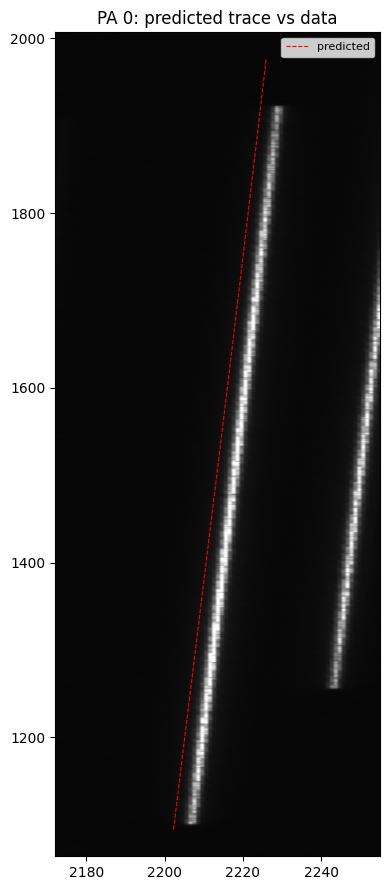

In [35]:
SRC_ID = 5                          # a bright, well-placed source
ra, dec = cat[SRC_ID]
tr_raw = geom[0].trace(ra, dec, lam)

y0=max(int(tr_raw[:,1].min())-30,0); y1=min(int(tr_raw[:,1].max())+30,SCA_SIZE)
x0=max(int(tr_raw[:,0].min())-30,0); x1=min(int(tr_raw[:,0].max())+30,SCA_SIZE)
sub = np.asarray(frames[0][y0:y1, x0:x1], float)

plt.figure(figsize=(4, 9))
plt.imshow(sub, origin="lower", vmin=0, vmax=np.percentile(sub, 99.5),
           cmap="gray", extent=[x0, x1, y0, y1], aspect="auto")
plt.plot(tr_raw[:,0], tr_raw[:,1], "r--", lw=0.8, label="predicted")
plt.legend(fontsize=8); plt.title("PA 0: predicted trace vs data")
plt.tight_layout(); plt.show()

## Measuring and correcting the offset

Strategy: straighten first, then measure.

`trace_strip` lays a 25-pixel-wide "ladder" along the predicted line — at every
wavelength it samples the image at 25 points perpendicular to the local trace
direction (bilinear interpolation at fractional pixels). The result is a
rectified strip: columns are wavelength, rows are perpendicular distance. If
the prediction were perfect, the flux would run along the middle row.

`estimate_offset` then cuts the ~930 columns into 8 chunks, stacks each chunk
into one high-S/N cross-dispersion profile (stacking ~112 columns buys a ~10x
S/N gain), and centroids the peak: 8 measurements of "how many rows off is the
flux". `correct_offset` fits a line through them — intercept = shift,
slope = tilt — and moves the trace onto the data. Residuals after correction
should be well under 0.2 px.

In [36]:
#The optical model predicts the trace position at every wavelength.
#trace_strip stores detector intensity 12 pixels on each side on the predicted trace.
# stamp stores the intensity, offs stores eeach rows distance from the predicted trace
def trace_strip(data, trace_xy, half_width=12):
    """Resample a strip along the predicted trace.
    Columns = wavelength, rows = perpendicular offset."""
    tang = np.gradient(trace_xy, axis=0)
    tang /= np.hypot(tang[:,0], tang[:,1])[:,None]
    nvec = np.column_stack([-tang[:,1], tang[:,0]])
    offs = np.arange(-half_width, half_width+1, dtype=float)
    xx = trace_xy[None,:,0] + offs[:,None]*nvec[None,:,0]
    yy = trace_xy[None,:,1] + offs[:,None]*nvec[None,:,1]
    stamp = map_coordinates(np.asarray(data, float), [yy, xx], order=1, mode="constant", cval=np.nan)
    return stamp, offs

#Keeps only the portions of the trace that is within the detector.
#Uses trace_strip to read and store detector intensity values at any specific (x,y) position
# Divide the spectrum into 8 wavelength chunks
#In each section it finds the intensity centroid of the real trace and cross-dispersion offset from the predicted trace
#Returns: sc=position along the spectrum and oc=meaure offset in pixels
def estimate_offset(pa, tr, hw=12, nbins=8):
    """Distance between data and prediction, at nbins points along
    the trace. Returns (chunk centers, offsets) or None."""
    ok = ((tr[:,0]>hw)&(tr[:,0]<SCA_SIZE-hw)&(tr[:,1]>hw)&(tr[:,1]<SCA_SIZE-hw))
    t = tr[ok]
    if t.shape[0] < 50: return None
    y0=max(int(t[:,1].min())-18,0); y1=min(int(t[:,1].max())+18,SCA_SIZE)
    x0=max(int(t[:,0].min())-18,0); x1=min(int(t[:,0].max())+18,SCA_SIZE)
    st, of = trace_strip(np.asarray(frames[pa][y0:y1,x0:x1],float), t-[x0,y0], hw)
    n = st.shape[1]
    edges = np.linspace(0, n, nbins+1, dtype=int)
    sc, oc = [], []
    for b in range(nbins):
        prof = np.nanmedian(st[:, edges[b]:edges[b+1]], axis=1)
        prof = np.clip(prof - np.nanmedian(prof[np.abs(of)>=hw-2]), 0, None)
        if prof.sum() <= 0: continue
        srch = np.abs(of) <= 8
        jpk = np.where(srch)[0][np.nanargmax(prof[srch])]
        win = slice(max(jpk-3,0), min(jpk+4, of.size))
        if prof[win].sum() <= 0: continue
        sc.append(0.5*(edges[b]+edges[b+1]))
        oc.append(float((of[win]*prof[win]).sum()/prof[win].sum()))
    if len(sc) < 3: return None
    return np.array(sc), np.array(oc)

#Fits a tilted straight line.
#Corrects for til and offset and returns the corected trace centroid.
def correct_offset(pa, ra, dec, hw=12, niter=2):
    """Fit shift + tilt through the measurements and move the trace.
    Returns (corrected trace, shift at mid-trace [px], tilt end-to-end [px])."""
    g = geom[pa]; tr = g.trace(ra, dec, lam)
    d = tr[-1]-tr[0]; u = d/np.hypot(*d); nvec = np.array([-u[1], u[0]])
    s = np.arange(tr.shape[0], dtype=float)
    corr = np.zeros(tr.shape[0]); a = b = 0.0
    for _ in range(niter):
        res = estimate_offset(pa, tr + corr[:,None]*nvec[None,:], hw)
        if res is None: break
        sc, oc = res
        bb, aa = np.polyfit(sc, oc, 1)
        a += aa; b += bb
        corr = a + b*s
        if np.max(np.abs(aa + bb*sc)) < 0.05: break
    tilt_px = b*(s[-1]-s[0])
    return tr + corr[:,None]*nvec[None,:], a + b*s[len(s)//2], tilt_px

tr_fix, shift_mid, tilt = correct_offset(0, ra, dec)
print(f"PA0: shift {shift_mid:+.2f} px at mid-trace, tilt {tilt:+.2f} px end-to-end")
chk = estimate_offset(0, tr_fix)
if chk is not None:
    print("leftover offset per bin [px]:", np.round(chk[1], 2))

PA0: shift -3.82 px at mid-trace, tilt +0.01 px end-to-end
leftover offset per bin [px]: [-0.    0.    0.01  0.01 -0.    0.01  0.   -0.  ]


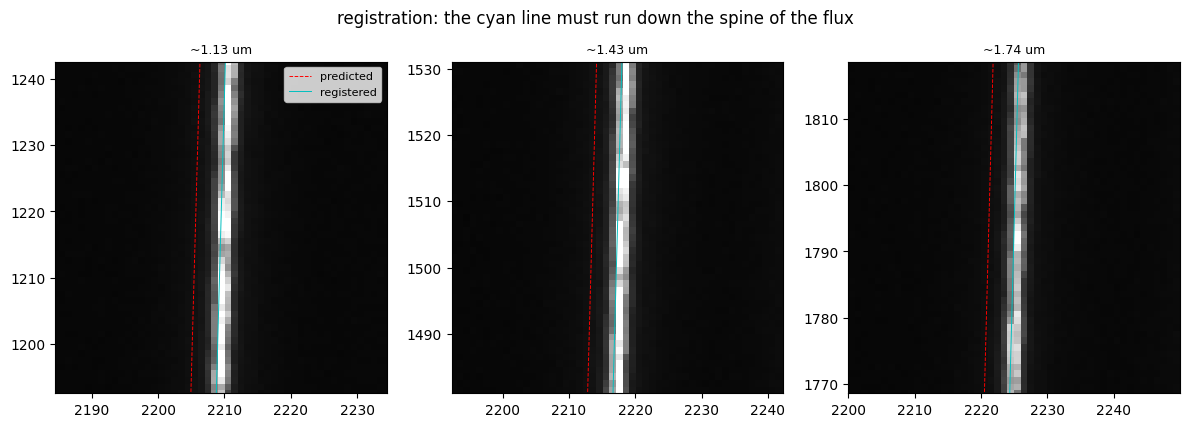

In [37]:
# Before/after, zoomed to ~1:1 pixels where sub-pixel alignment is judgeable. Simulated throughput ends ~1.87 um
lam_lit = lam[lam <= 1.865]                    
tr_r = geom[0].trace(ra, dec, lam_lit)
tr_c = tr_fix[:lam_lit.size]

y0=max(int(tr_r[:,1].min())-30,0); y1=min(int(tr_r[:,1].max())+30,SCA_SIZE)
x0=max(int(tr_r[:,0].min())-30,0); x1=min(int(tr_r[:,0].max())+30,SCA_SIZE)
subc = np.asarray(frames[0][y0:y1, x0:x1], float)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
picks = [0.15, 0.5, 0.85]
for ax, f in zip(axes, picks):
    i = int(f*lam_lit.size)
    cx, cy = tr_c[i]
    ax.imshow(subc, origin="lower", cmap="gray",
              vmin=0, vmax=np.percentile(subc, 99.5),
              extent=[x0, x1, y0, y1])
    ax.plot(tr_r[:,0], tr_r[:,1], "r--", lw=0.7, label="predicted")
    ax.plot(tr_c[:,0], tr_c[:,1], "c-",  lw=0.7, label="registered")
    ax.set_xlim(cx-25, cx+25); ax.set_ylim(cy-25, cy+25)
    ax.set_title(f"~{lam_lit[i]:.2f} um", fontsize=9)
axes[0].legend(fontsize=8)
plt.suptitle("registration: the cyan line must run down the spine of the flux")
plt.tight_layout(); plt.show()

## Background: measure it, then subtract it locally

The frames carry a flat zodiacal background plus read noise. We need two
numbers: the noise level (for the extraction weights) and the background level
(to subtract).

The field is far too crowded to pick empty regions by hand, so we select
source-free *pixels*: iteratively clip everything more than 3 sigma above the
running median (traces only add flux, so only the high side gets clipped);
what survives is background. Its median is the sky, its MAD-scatter the noise.

One honest caveat, and it matters in a field this crowded: faint trace wings
below the 3-sigma cut survive the clip, so the global median is biased
slightly high — we measured +0.009 e-/s here. Nine aperture rows times that is
~0.08 e-/s per column, a real bite out of a faint source. So the global value
is used only for the noise floor and display stretches; the *subtraction* is
done locally, per wavelength column, from the strip rows outside the aperture
(|offset| >= 8 px). That kills the global bias and tracks any gradient for free.

PA   0:  background 0.816 e-/s   noise 0.0507 e-/s   pixels used 95%
PA 150:  background 0.813 e-/s   noise 0.0507 e-/s   pixels used 95%
PA 182:  background 0.816 e-/s   noise 0.0507 e-/s   pixels used 95%
PA 214:  background 0.813 e-/s   noise 0.0507 e-/s   pixels used 96%


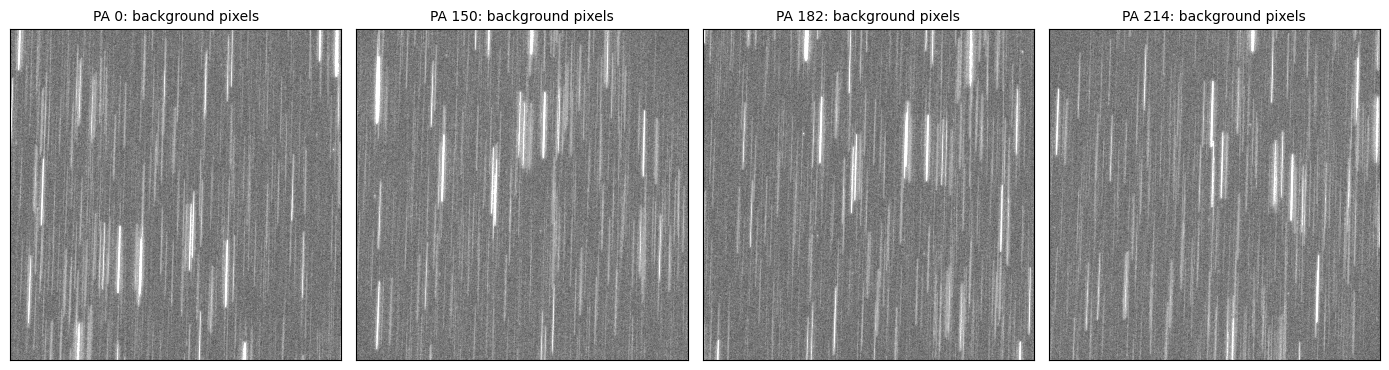


using SKY=0.814 e-/s (display only), noise=0.0507 e-/s


In [38]:
def background_pixels(img, nsigma=3.0, niter=6):
    d = np.asarray(img[::4, ::4], float)
    keep = np.isfinite(d)
    assert keep.any(), "frame slice is all-NaN"
    for _ in range(niter):
        med = np.median(d[keep])
        sig = 1.4826 * np.median(np.abs(d[keep] - med))
        new = keep & (d < med + nsigma * sig)
        if new.sum() == keep.sum(): break
        keep = new
    med = float(np.median(d[keep]))
    sig = float(1.4826 * np.median(np.abs(d[keep] - med)))
    return med, sig, keep, d

skys, sigs = [], []
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, pa in zip(axes, ROLLS):
    sky, sig, keep, d = background_pixels(frames[pa])
    skys.append(sky); sigs.append(sig)
    print(f"PA {pa:>3}:  background {sky:.3f} e-/s   noise {sig:.4f} e-/s   "
          f"pixels used {keep.mean()*100:.0f}%")
    ax.imshow(np.where(keep, d, np.nan), origin="lower", cmap="gray",vmin=sky-3*sig, vmax=sky+3*sig)
    ax.set_title(f"PA {pa}: background pixels", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

SKY, SIG_SKY = float(np.median(skys)), float(np.median(sigs))
assert np.isfinite(SIG_SKY) and SIG_SKY > 0, f"SIG_SKY bad: {SIG_SKY}"
print(f"\nusing SKY={SKY:.3f} e-/s (display only), noise={SIG_SKY:.4f} e-/s")

## Box vs Horne extraction

Collapse the strip to one flux per wavelength column. Two ways:

**Box**: add the rows within +/-4 px of the trace. Simple, unbiased — but a
noisy edge pixel counts as much as the bright core.

**Horne (1986) optimal**: weight each row by (its share of the source profile)
divided by (its variance): flux = sum(P D / V) / sum(P^2 / V). Bright rows
count more, noisy rows less. For background-dominated (faint) sources the S/N
gain is 10-20%; for bright sources the two are nearly identical — which is
itself a useful sanity check. The profile P is the wavelength-median of the
strip, i.e. we assume the source shape doesn't change across the band (fine
for compact sources).

Variance model: source Poisson (rate/t_exp) on top of the measured background
noise floor.

wing residual after local subtraction: +0.0000 e-/s (should be ~0)
median S/N per column:  box 147.4   optimal 149.3


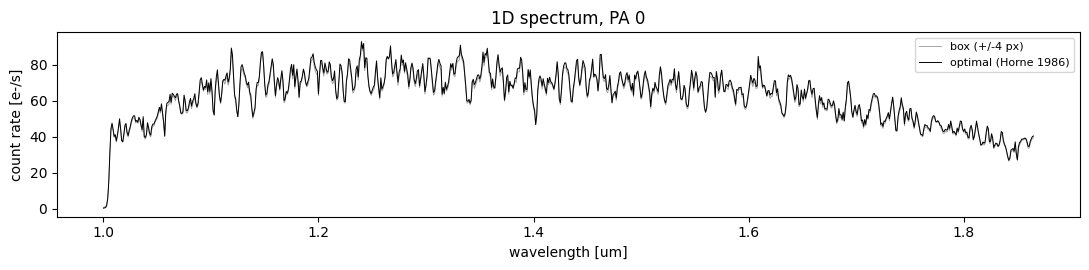

In [39]:
def extract_box(clean_stamp, offs, variance, aperture=4):
    m = np.abs(offs) <= aperture
    d = np.where(np.isfinite(clean_stamp[m,:]), clean_stamp[m,:], 0.0)
    v = np.where(np.isfinite(variance[m,:]),   variance[m,:],   0.0)
    return d.sum(axis=0), np.sqrt(v.sum(axis=0))

def extract_optimal(clean_stamp, offs, variance, aperture=6):
    m = np.abs(offs) <= aperture
    D = np.where(np.isfinite(clean_stamp[m,:]), clean_stamp[m,:], 0.0)
    V = np.where(np.isfinite(variance[m,:]),   variance[m,:],   np.inf)
    P = np.clip(np.nanmedian(D, axis=1), 0.0, None)
    if P.sum() <= 0:
        return extract_box(clean_stamp, offs, variance, aperture)
    P = (P / P.sum())[:, None]
    num = np.sum(P * D / V, axis=0)
    den = np.sum(P**2 / V, axis=0)
    den = np.where(den > 0, den, np.nan)
    return num / den, np.sqrt(1.0 / den)

# demo on our registered source, PA 0
ok = ((tr_c[:,0]>12)&(tr_c[:,0]<SCA_SIZE-12)&(tr_c[:,1]>12)&(tr_c[:,1]<SCA_SIZE-12))
t, lr = tr_c[ok], lam_lit[ok]
y0=max(int(t[:,1].min())-18,0); y1=min(int(t[:,1].max())+18,SCA_SIZE)
x0=max(int(t[:,0].min())-18,0); x1=min(int(t[:,0].max())+18,SCA_SIZE)
st, offs = trace_strip(np.asarray(frames[0][y0:y1,x0:x1],float), t-[x0,y0], 12)

wing = np.abs(offs) >= 8
clean = st - np.nanmedian(st[wing,:], axis=0)[None,:]   # LOCAL background
print("wing residual after local subtraction: "
      f"{np.nanmedian(clean[wing,:]):+.4f} e-/s (should be ~0)")

var = np.maximum(clean, 0)/T_EFF + SIG_SKY**2
flux_box, err_box = extract_box(clean, offs, var)
flux_opt, err_opt = extract_optimal(clean, offs, var)
print(f"median S/N per column:  box {np.nanmedian(flux_box/err_box):.1f}   "
      f"optimal {np.nanmedian(flux_opt/err_opt):.1f}")

plt.figure(figsize=(11, 2.8))
plt.plot(lr, flux_box, "-", color="0.6", lw=0.6, label="box (+/-4 px)")
plt.plot(lr, flux_opt, "k-", lw=0.7, label="optimal (Horne 1986)")
plt.fill_between(lr, flux_opt-err_opt, flux_opt+err_opt, color="0.7", alpha=0.5, lw=0)
plt.xlabel("wavelength [um]"); plt.ylabel("count rate [e-/s]")
plt.legend(fontsize=8); plt.title("1D spectrum, PA 0")
plt.tight_layout(); plt.show()

## Flux calibration — count rate to physical units

F_lambda [erg/s/cm^2/A] = rate x (hc/lambda) / (A_eff x dlambda). Each electron
carries a photon of energy hc/lambda; A_eff is the collecting area times the
full system throughput (mirrors, optics, grism, filter, contamination,
detector QE); dlambda is one column's width (10 A).

A_eff comes straight from `grism_11_espresso.txt` — the throughput table the
simulation itself used — so the absolute scale can be checked against the
known inputs. Bandpass: 0.976-1.898 um, zero outside (the simulator also has a
field-dependent blue cutoff, so the extreme blue edge is approximate).

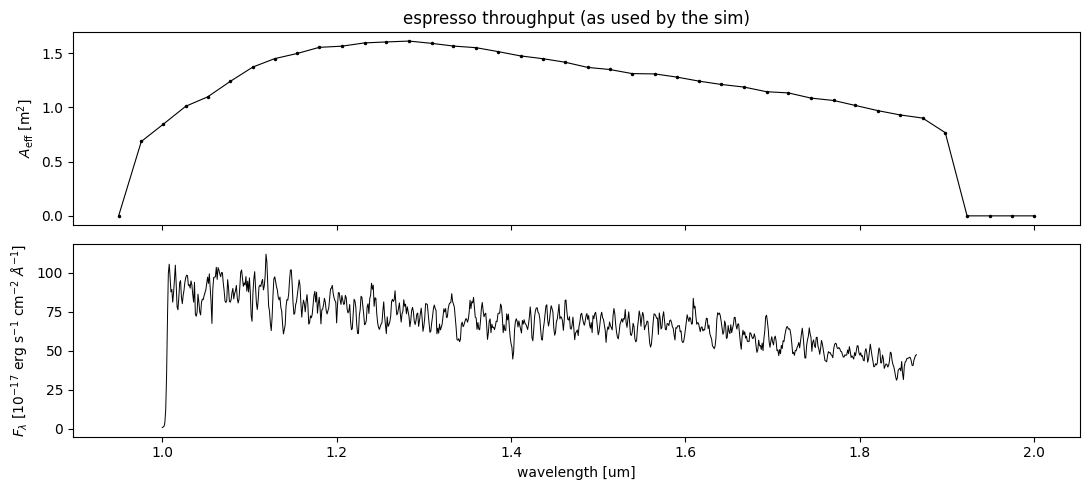

median F_lambda: 6.83e-16 erg/s/cm2/A


In [48]:
H_C = 1.98645e-8               # h*c [erg*Angstrom]

_esp = np.loadtxt("grism_11_espresso.txt", comments=";")
_ESP_LAM, _ESP_AEFF_CM2 = _esp[:, 0], _esp[:, -1] * 1e4    # m^2 -> cm^2
_NZ = _ESP_AEFF_CM2 > 0

def a_eff_cm2(lam_um):
    return np.interp(np.asarray(lam_um, float), _ESP_LAM[_NZ],
                     _ESP_AEFF_CM2[_NZ], left=0.0, right=0.0)

def calibrate(lam_um, rate, rate_err):
    """e-/s per column -> F_lambda. NaN outside the bandpass, never inf."""
    lam_A = np.asarray(lam_um) * 1e4
    dlam_A = np.gradient(lam_A)
    a = a_eff_cm2(lam_um)
    conv = np.where(a > 0, (H_C/lam_A) / np.where(a > 0, a, 1.0) / dlam_A, np.nan)
    return rate * conv, rate_err * conv

flam, flam_err = calibrate(lr, flux_opt, err_opt)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(_ESP_LAM, _ESP_AEFF_CM2/1e4, "k.-", lw=0.8, ms=3)
a1.set_ylabel(r"$A_{\rm eff}$ [m$^2$]"); a1.set_title("espresso throughput (as used by the sim)")
a2.plot(lr, flam/1e-17, "k-", lw=0.7)
a2.fill_between(lr, (flam-flam_err)/1e-17, (flam+flam_err)/1e-17,color="0.7", alpha=0.5, lw=0)
a2.set_xlabel("wavelength [um]")
a2.set_ylabel(r"$F_\lambda$ [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")
plt.tight_layout(); plt.show()
print(f"median F_lambda: {np.nanmedian(flam):.2e} erg/s/cm2/A")

## Contamination — first, look at the images

In slitless spectroscopy every object disperses, so neighbouring spectra can overlap. A contaminant may appear as a second band, or it may land almost exactly on the target and only make one roll brighter. Multiple rolls do not automatically subtract contamination; they give independent projections that let us identify and reject suspect measurements.

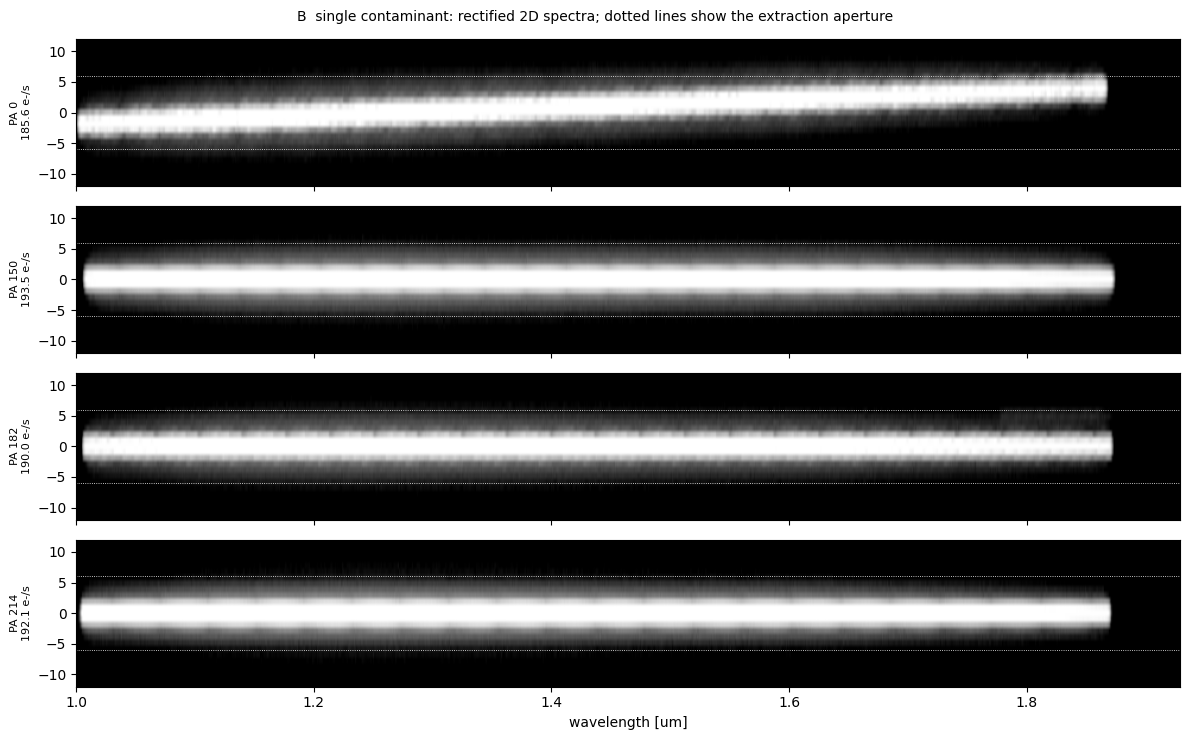

In [41]:
SOURCES = [
    ("A  isolated",           150.133807, 2.343347),
    ("B  single contaminant", 150.146726, 2.361445),
    ("C  multiple",           150.076563, 2.330513),
    ("D  uncatalogued",       150.136774, 2.387549),
]
APERTURE = 6

def rectify(pa, ra, dec, half_width=12):
    """Register the trace and resample a perpendicular strip."""
    tr, sh, ti = correct_offset(pa, ra, dec, half_width)
    ok = ((tr[:,0] > half_width) & (tr[:,0] < SCA_SIZE-half_width) & (tr[:,1] > half_width) & (tr[:,1] < SCA_SIZE-half_width))
    if ok.sum() < 10: return None
    t, lam_r = tr[ok], lam[ok]
    y0, y1 = max(int(t[:,1].min())-18, 0), min(int(t[:,1].max())+18, SCA_SIZE)
    x0, x1 = max(int(t[:,0].min())-18, 0), min(int(t[:,0].max())+18, SCA_SIZE)
    st, of = trace_strip(np.asarray(frames[pa][y0:y1, x0:x1], float), t-[x0,y0], half_width)
    return dict(lam=lam_r, strip=st, offs=of, trace=t, shift=sh, tilt=ti)

name_demo, ra_b, dec_b = SOURCES[1]
fig, axes = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
for ax, pa in zip(axes, ROLLS):
    r = rectify(pa, ra_b, dec_b)
    if r is None: ax.set_ylabel(f"PA {pa}\n(off det.)", fontsize=8); continue
    st, of = r["strip"], r["offs"]
    med = np.nanmedian(st); mad = max(1.4826*np.nanmedian(np.abs(st-med)), 1e-12)
    ax.imshow(np.arcsinh((st-med)/mad), origin="lower", cmap="gray", vmin=0, vmax=np.arcsinh(30), extent=[r["lam"][0], r["lam"][-1], of[0], of[-1]], aspect="auto")
    ax.axhline(+APERTURE, color="w", ls=":", lw=0.6); ax.axhline(-APERTURE, color="w", ls=":", lw=0.6)
    clean = st - np.nanmedian(st[np.abs(of) >= 8], axis=0)[None,:]
    rate = np.nanmedian(np.nansum(clean[np.abs(of) <= APERTURE], axis=0))
    ax.set_ylabel(f"PA {pa}\n{rate:.1f} e-/s", fontsize=8)
axes[-1].set_xlabel("wavelength [um]")
fig.suptitle(f"{name_demo}: rectified 2D spectra; dotted lines show the extraction aperture", fontsize=10)
fig.tight_layout(); plt.show()

## Contamination screening and roll combination

The tutorial now uses three checks that actually feed the final result:

1. **Geometry:** full curved catalogue traces are projected onto the detector; only the matched target is excluded from the neighbour list.
2. **Broadband roll check:** a roll more than 10% brighter than the lowest roll over common wavelength coverage is rejected.
3. **Per-column check:** a positive excess is rejected at 4 sigma after including a 3% roll-to-roll systematic floor.

Clean measurements are inverse-variance combined. If no clean roll remains, the spectrum is left missing rather than converted into a false upper limit. This is conservative screening, not model-based flux subtraction.

In [42]:
from scipy.spatial import cKDTree

# Curved catalogue traces are reused for every target (~30 MB for four rolls).
CAT_TRACES = {pa: np.stack([geom[pa].trace(float(r), float(d), lam) for r, d in cat]) for pa in ROLLS}

#Calculate the difference between the predicted trace and the corrected target trace.
#Apply that correction to the predicted traces of all catalog sources.
#Remove the target itself from the list of possible contaminants.
#At every target wavelength, find the nearest point on another source’s trace.
#Mark the wavelength True if that trace comes within aperture (6 pixels) + source_radius pixels (2 pixels). Total= 8 pixels

def contamination_mask(pa, ra, dec, lam_r, target_trace, aperture=APERTURE, source_radius=2):
    """Flag wavelengths whose extraction footprint meets another curved trace."""
    g = geom[pa]; raw = g.trace(ra, dec, lam_r)
    delta = np.column_stack([np.interp(lam, lam_r, target_trace[:,q]-raw[:,q]) for q in range(2)])
    sep = 3600*np.hypot((cat[:,0]-ra)*np.cos(np.deg2rad(dec)), cat[:,1]-dec)
    self_id = int(np.argmin(sep)) if np.min(sep) <= 0.03 else -1
    traces = CAT_TRACES[pa] + delta[None,:,:]
    cloud = traces[np.arange(len(cat)) != self_id].reshape(-1, 2)
    cloud = cloud[np.isfinite(cloud).all(axis=1)]
    if not len(cloud): return np.zeros(lam_r.size, bool)
    return cKDTree(cloud).query(target_trace, k=1)[0] <= aperture + source_radius

#Follow the corrected target trace and create a straight 2D spectral strip around it.
#Estimate the local background from pixels far from the trace and subtract it.
#Combine the signal inside the aperture to produce a 1D count-rate spectrum.
#Convert the count-rate spectrum into calibrated physical flux with uncertainties.
#Flag wavelengths where another source’s trace may contaminate the target spectrum.

def extract_roll(pa, ra, dec, half_width=12, aperture=APERTURE):
    """Rectify, subtract local background, extract, calibrate and flag."""
    r = rectify(pa, ra, dec, half_width)
    if r is None: return None
    st, of = r["strip"], r["offs"]
    clean = st - np.nanmedian(st[np.abs(of) >= 8], axis=0)[None,:]
    variance = np.maximum(clean, 0)/T_EFF + SIG_SKY**2
    rate, rate_err = extract_optimal(clean, of, variance, aperture=aperture)
    flux, err = calibrate(r["lam"], rate, rate_err)
    mask = contamination_mask(pa, ra, dec, r["lam"], r["trace"], aperture)
    return dict(lam=r["lam"], flux=flux, err=err, rate=rate, mask=mask)

#Put every roll-angle spectrum on the same wavelength grid.
#Remove measurements already flagged by the geometric contamination mask. 
#Also reject an entire roll if its median rate is more than 10% above the lowest roll.
#At each wavelength, use the lowest remaining flux as the contamination reference.
# Mask any other roll whose flux is significantly higher than that reference—more than 4σ.
#Combine the remaining clean roll measurements using an uncertainty-weighted average.

def combine_rolls(per_roll, systematic=0.03, clip=4.0, roll_tolerance=0.10):
    """Reject geometric and measured positive excesses, then combine."""
    rolls = [pa for pa, r in per_roll.items() if r is not None]
    if not rolls: raise ValueError("No roll covers this target")
    shape = (len(rolls), len(lam)); F = np.full(shape, np.nan); E = np.full(shape, np.nan); R = np.full(shape, np.nan); M = np.ones(shape, bool)
    for i, pa in enumerate(rolls):
        r = per_roll[pa]; j = np.searchsorted(lam, r["lam"])
        F[i,j], E[i,j], R[i,j], M[i,j] = r["flux"], r["err"], r["rate"], r["mask"]
    covered = np.isfinite(F) & np.isfinite(E) & (E > 0)
    common = np.all(covered & np.isfinite(R), axis=0)
    ratio = np.full(len(rolls), np.nan); bad_roll = np.zeros(len(rolls), bool)
    if common.sum() >= 20:
        med = np.nanmedian(R[:,common], axis=1); positive = np.isfinite(med) & (med > 0)
        if positive.any(): ratio[positive] = med[positive]/np.min(med[positive]); bad_roll = ratio > 1 + roll_tolerance
    candidate = covered & ~M & ~bad_roll[:,None]
    measured = np.zeros(shape, bool)
    for j in np.flatnonzero(candidate.sum(axis=0) >= 2):
        rows = np.flatnonzero(candidate[:,j]); ref = rows[np.argmin(F[rows,j])]
        scale = np.maximum(np.abs(F[rows,j]), abs(F[ref,j])); sigma = np.sqrt(E[rows,j]**2 + E[ref,j]**2 + 2*(systematic*scale)**2)
        measured[rows,j] = F[rows,j]-F[ref,j] > clip*sigma
    good = candidate & ~measured; n_clean = good.sum(axis=0)
    weight = np.zeros(shape); weight[good] = 1/E[good]**2; weight_sum = weight.sum(axis=0)
    flux = np.sum(np.where(good, F*weight, 0), axis=0)/np.where(weight_sum > 0, weight_sum, np.nan)
    err = np.sqrt(1/np.where(weight_sum > 0, weight_sum, np.nan) + (systematic*np.abs(flux))**2)
    variance = E**2 + (systematic*np.maximum(np.abs(F), np.abs(flux)[None,:]))**2
    chi2 = np.sum(np.where(good, (F-flux)**2/variance, 0), axis=0)
    chi2_red = np.full(len(lam), np.nan); enough = n_clean >= 2; chi2_red[enough] = chi2[enough]/(n_clean[enough]-1)
    n_available = covered.sum(axis=0)
    return dict(lam=lam, flux=flux, err=err, n_clean=n_clean, no_coverage=n_available==0, no_clean=(n_available>0)&(n_clean==0), chi2_red=chi2_red, rolls=rolls, roll_ratio=dict(zip(rolls,ratio)), roll_bad=dict(zip(rolls,bad_roll)), geometry_mask=M, measured_mask=measured, good_mask=good)

per_all = {name: {pa: extract_roll(pa, r, d) for pa in ROLLS} for name, r, d in SOURCES}

print("median optimal-extraction rate relative to the lowest roll; * = rejected")
for name, per in per_all.items():
    c = combine_rolls(per)
    line = "  ".join(f"PA{pa}:{c['roll_ratio'][pa]:.2f}x{'*' if c['roll_bad'][pa] else ''}" for pa in c["rolls"])
    print(f"{name:<24} {line}")

median optimal-extraction rate relative to the lowest roll; * = rejected
A  isolated              PA0:1.00x  PA150:1.03x  PA182:1.01x  PA214:1.03x
B  single contaminant    PA0:1.00x  PA150:3.20x*  PA182:3.13x*  PA214:3.17x*
C  multiple              PA0:1.80x*  PA150:1.90x*  PA182:1.00x  PA214:1.70x*
D  uncatalogued          PA0:1.00x  PA150:2.12x*  PA182:2.12x*  PA214:2.15x*


## Screened, combined spectra

Black shows each roll, blue is the lowest measured roll at each wavelength, orange marks positive excesses rejected by the actual combination, and gray points mark catalogue-trace overlaps. The bottom panel contains only accepted measurements. Red ticks indicate wavelengths with data but no accepted roll; they are gaps, not upper limits.

The isolated source is the null test. Its reduced chi-square should be near one after the systematic floor is included. If it is not, the registration, calibration, aperture loss or uncertainty model still needs work.

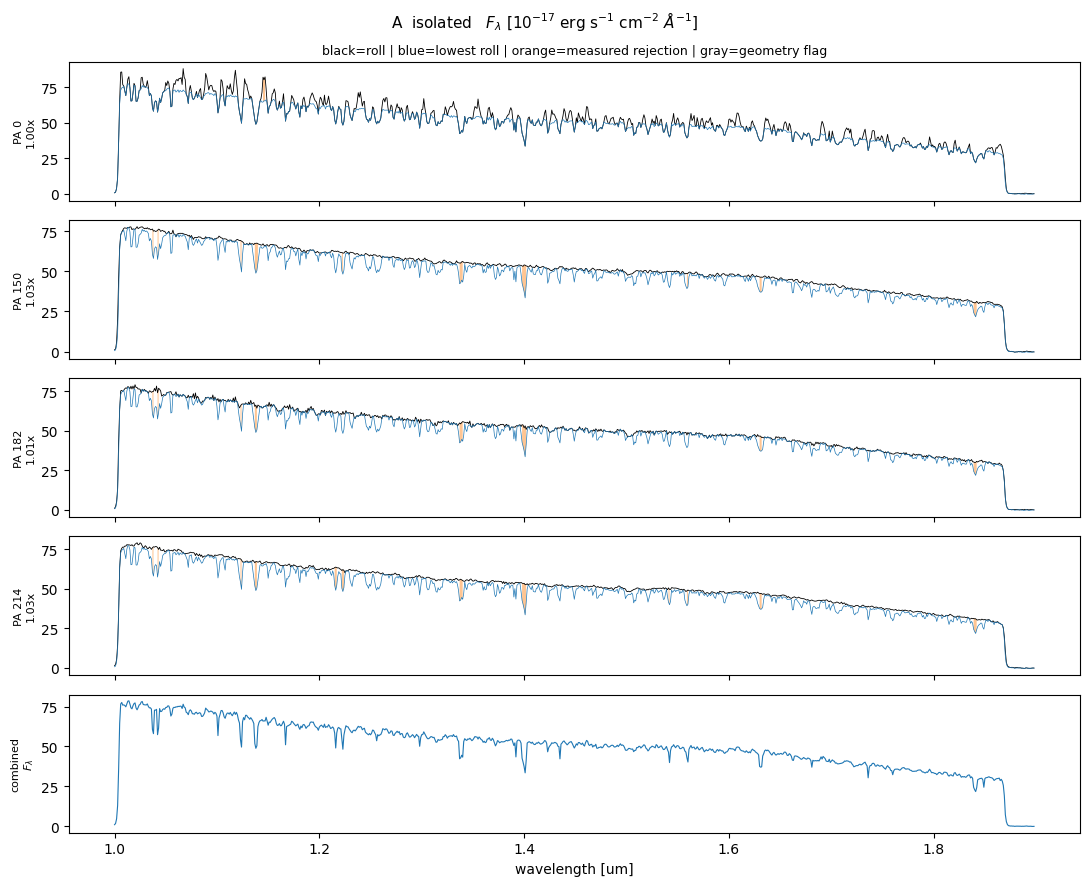

A  isolated              clean>=2  92.9%   no-clean  0.0%   no-coverage  3.3%   med chi2 1.22


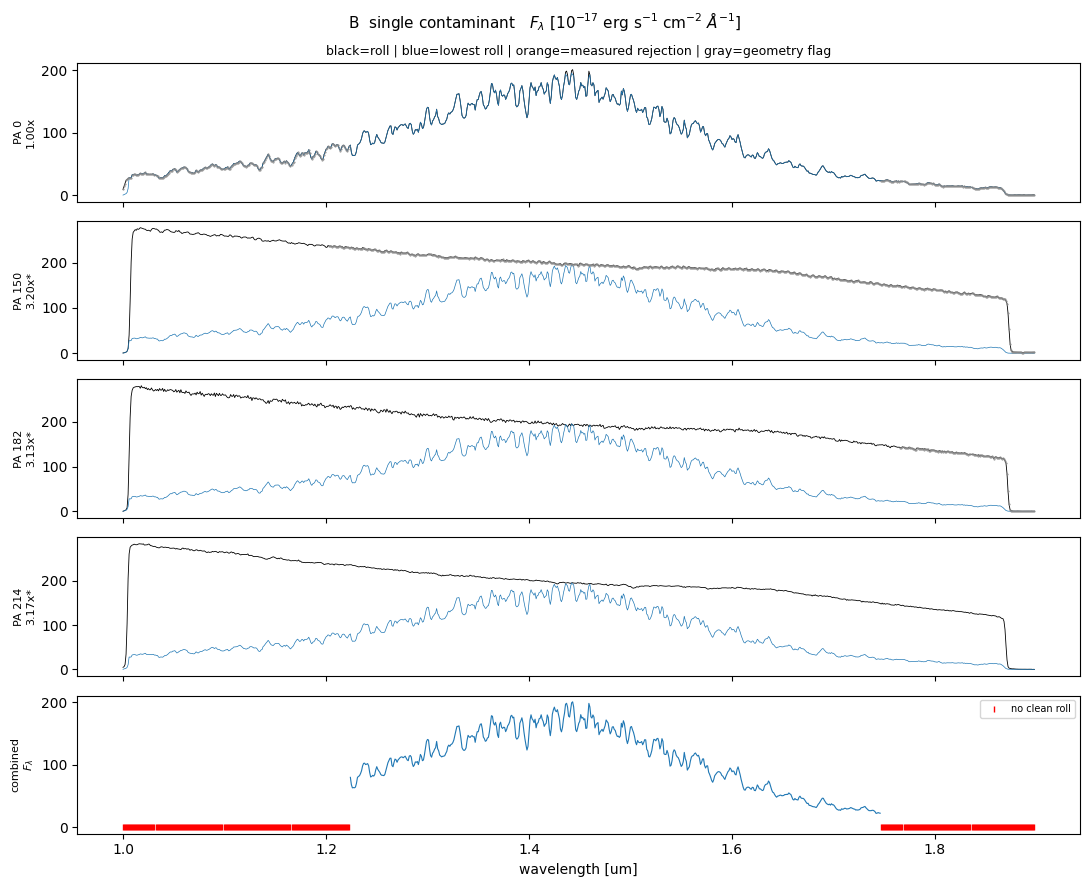

B  single contaminant    clean>=2   0.0%   no-clean 40.4%   no-coverage  3.3%   med chi2 nan


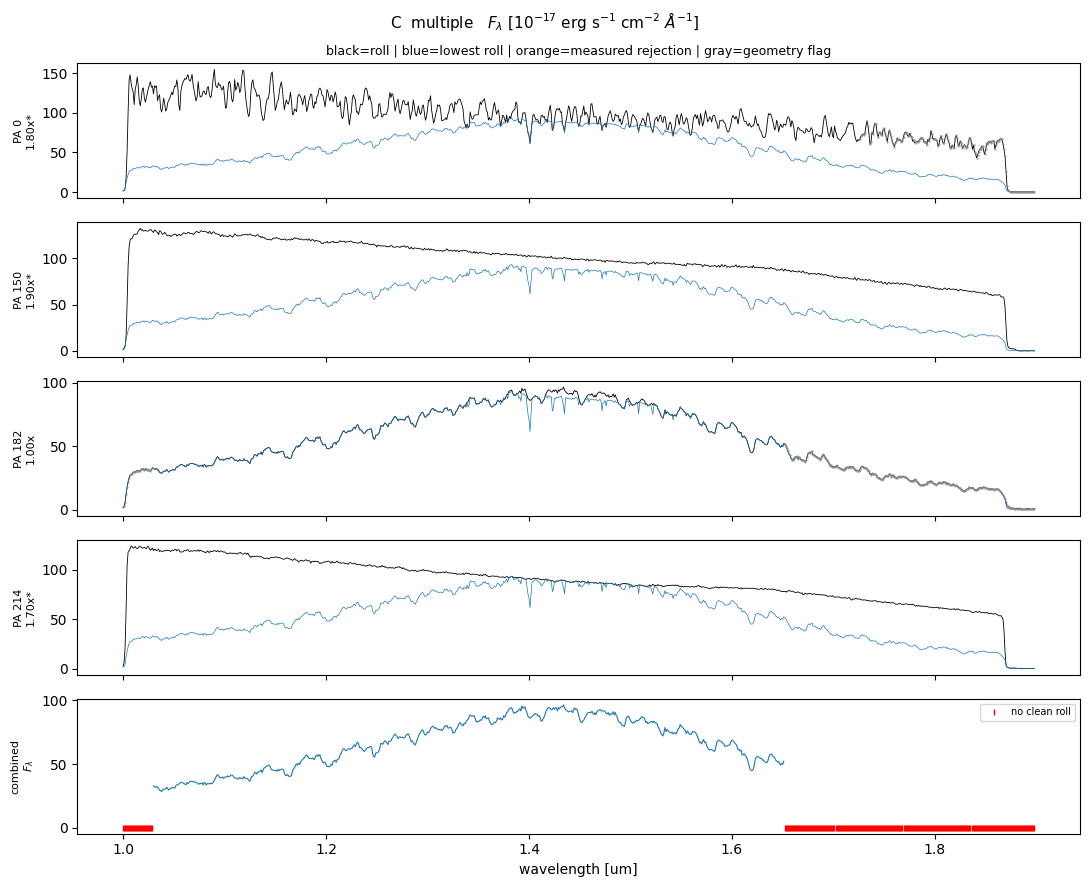

C  multiple              clean>=2   0.0%   no-clean 29.8%   no-coverage  3.3%   med chi2 nan


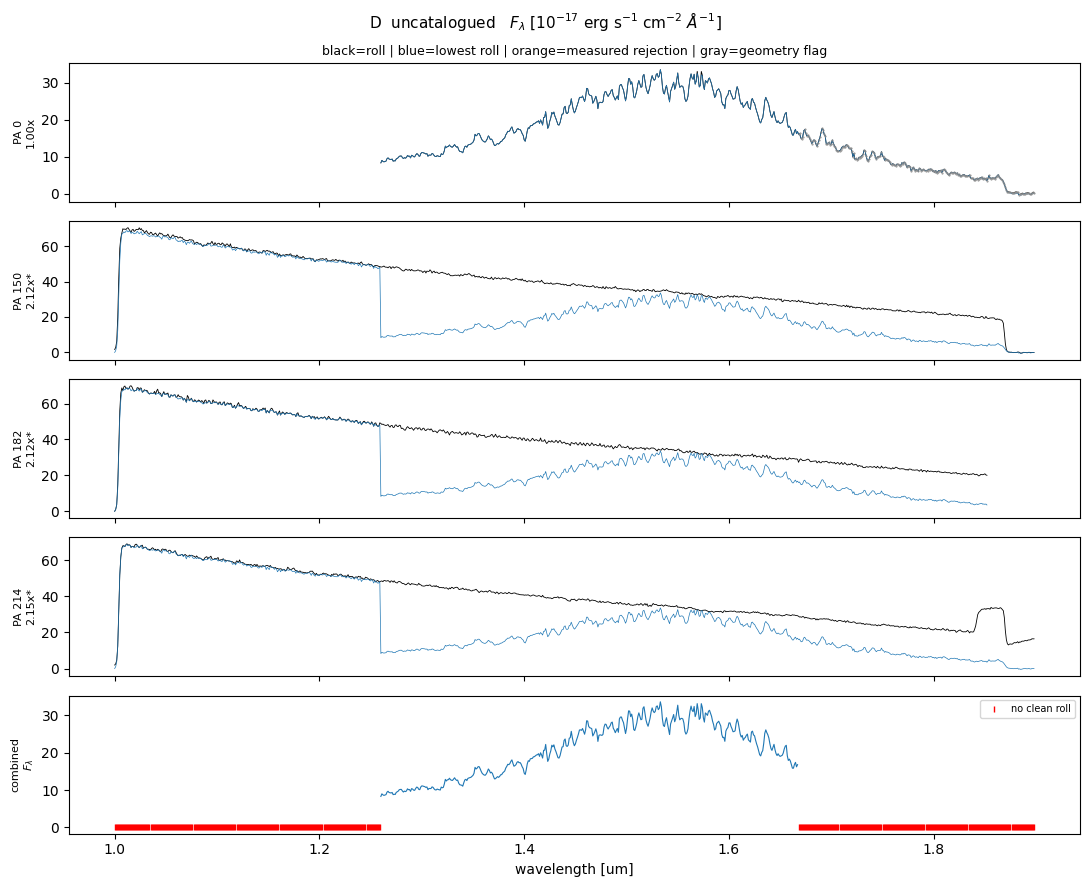

D  uncatalogued          clean>=2   0.0%   no-clean 52.8%   no-coverage  3.3%   med chi2 nan


In [43]:
for name, per in per_all.items():
    comb = combine_rolls(per); valid = comb["rolls"]; row = {pa:i for i,pa in enumerate(valid)}
    Fs = np.full((len(valid), len(lam)), np.nan)
    for i, pa in enumerate(valid): Fs[i,np.searchsorted(lam,per[pa]["lam"])] = per[pa]["flux"]
    has_flux = np.isfinite(Fs).any(axis=0); Fmin = np.full(len(lam), np.nan); Fmin[has_flux] = np.nanmin(Fs[:,has_flux], axis=0)
    fig, ax = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
    for a, pa in zip(ax[:4], ROLLS):
        r = per[pa]
        if r is None: a.set_ylabel(f"PA {pa}\n(off det.)", fontsize=8); continue
        j = np.searchsorted(lam, r["lam"]); low = Fmin[j]; measured = comb["measured_mask"][row[pa],j]; geometric = comb["geometry_mask"][row[pa],j]
        a.plot(r["lam"], r["flux"]/1e-17, "k-", lw=0.6); a.plot(r["lam"], low/1e-17, color="tab:blue", lw=0.5)
        a.fill_between(r["lam"], low/1e-17, r["flux"]/1e-17, where=measured, color="tab:orange", alpha=0.45, lw=0)
        a.plot(r["lam"][geometric], r["flux"][geometric]/1e-17, ".", color="0.55", ms=1)
        mark = "*" if comb["roll_bad"][pa] else ""; a.set_ylabel(f"PA {pa}\n{comb['roll_ratio'][pa]:.2f}x{mark}", fontsize=8)
    ax[0].set_title("black=roll | blue=lowest roll | orange=measured rejection | gray=geometry flag", fontsize=9)
    ok = np.isfinite(comb["flux"]); ax[4].plot(lam[ok], comb["flux"][ok]/1e-17, color="tab:blue", lw=0.8)
    gap = comb["no_clean"]; ax[4].plot(lam[gap], np.zeros(gap.sum()), "r|", ms=4, label="no clean roll")
    if gap.any(): ax[4].legend(fontsize=7)
    ax[4].set_ylabel("combined\n$F_\\lambda$", fontsize=8); ax[4].set_xlabel("wavelength [um]")
    fig.suptitle(f"{name}   $F_\\lambda$ [$10^{{-17}}$ erg s$^{{-1}}$ cm$^{{-2}}$ $\\AA^{{-1}}$]", fontsize=11)
    fig.tight_layout(); plt.show()
    enough = comb["n_clean"] >= 2; med_chi2 = np.nanmedian(comb["chi2_red"][enough]) if enough.any() else np.nan
    print(f"{name:<24} clean>=2 {enough.mean()*100:5.1f}%   no-clean {comb['no_clean'].mean()*100:4.1f}%   no-coverage {comb['no_coverage'].mean()*100:4.1f}%   med chi2 {med_chi2:.3g}")

## Appendix — registration diagnostics

The table below shows how the fitted shift and tilt vary by source and roll. Scatter can come from genuine centroid differences, contamination, or failure of the trace fit; it does not by itself prove that every source needs an independent registration. A production pipeline should estimate registration from isolated calibration sources or fit a robust field-dependent model.

In [44]:
print("registration per source and roll: shift at mid-trace / tilt end-to-end [px]")
print(f"{'src':>4} " + "  ".join(f"{'PA'+str(pa):>13}" for pa in ROLLS))
shifts = []
for i in [2, 5, 10, 20, 50]:
    r_, d_ = cat[i]
    row = []
    for pa in ROLLS:
        try:
            _, sh, ti = correct_offset(pa, r_, d_)
            row.append((sh, ti))
        except Exception:
            row.append((np.nan, np.nan))
    shifts.append([x[0] for x in row])
    print(f"{i:>4} " + "  ".join(f"{sh:+6.2f}/{ti:+5.2f}" for sh, ti in row))
shifts = np.array(shifts)
print("\nper-roll median shift:", np.round(np.nanmedian(shifts, axis=0), 2),
      "  scatter:", np.round(np.nanstd(shifts, axis=0), 2))

registration per source and roll: shift at mid-trace / tilt end-to-end [px]
 src           PA0          PA150          PA182          PA214
   2  +1.76/-6.41   -0.61/+0.02   -2.07/-0.04   -2.73/+0.01
   5  -3.82/+0.01   +3.31/-2.13   +4.72/-0.59   +4.66/-0.02
  10  +2.58/-3.75   -0.92/-1.16   -1.10/+0.20   -0.80/+1.78
  20  +1.45/-1.91   -0.83/-0.94   -0.83/-0.83   -0.23/-0.17
  50  -0.92/-0.18   +1.53/-0.70   +1.84/-0.01   +1.57/-0.00

per-roll median shift: [ 1.45 -0.61 -0.83 -0.23]   scatter: [2.33 1.67 2.47 2.5 ]


---

# Your task: emission-line galaxies and their redshifts

Everything above extracts *continua*. The science target is **emission lines**:
find the emission-line galaxies in the catalogue and measure their redshifts.

**What to submit** — one plain-text file, one row per emission-line galaxy you
identify:

```
# RA_deg        Dec_deg       z
150.1467258     2.3614446     1.4213
...
```

Three columns: **RA, Dec** (from `catalog_radec.txt` — use the catalogue
positions, not your own re-centroids, so rows can be matched) and **z**, the
spectroscopic redshift from your extracted spectrum.

**Scoring.** We anticipate a paper describing the data challenge and participants 
who are significantly involved will be invited as co-authors on that paper.

Submit to **spqrdc332@gmail.com**, one `.txt` file, attached. Give yourself
time to run all four rolls — extraction is the fast part; deciding which
detections to trust is the slow one.

## Practical notes before you start

**Line identification is the science; here is the physics you need.** In
1.00–1.93 μm the workhorse lines and their observed-frame windows:

| Line | rest λ [μm] | visible for z in |
|---|---|---|
| Hα + [N II] | 0.6563 | 0.52 – 1.94 |
| [O III] 5007 | 0.5007 | 1.00 – 2.85 |
| Hβ | 0.4861 | 1.06 – 2.97 |
| [O II] 3727 | 0.3727 | 1.68 – 4.18 |

At R ≈ 461·λ, Hα and [N II] are blended; [O III] 4959/5007 is a partially
resolved pair — that 2:1 doublet asymmetry is often your best confirmation
that a line is [O III] and not Hα. A single unidentified line is ambiguous
(one line, several possible redshifts); two lines lock z. If you can only see
one, its shape and the absence of the partner lines elsewhere in the band are
your discriminants.

**Redshift precision.** One 10 Å column at Hα(z≈1) is Δz ≈ 0.0008. Report 4
decimal places; centroid the line, don't just take the brightest column.

**Contamination will fake lines.** A neighbour's emission line entering your
aperture at one roll looks exactly like a line in your spectrum. The defence
is built above: a real line appears at the same wavelength in *every clean
roll*; a contaminant line appears in one roll and vanishes in the others.
Never report a line seen in a single roll only.

**The catalogue is brightest-first and incomplete.** Work down the list —
bright continua are where lines are easiest to confirm — but remember
uncatalogued sources below 5σ are still dispersing onto your traces
(source D above is the worked example).

**Reuse the machinery.** `extract_roll` + `combine_rolls` give you a
combined, decontaminated spectrum per catalogue row in one call each. A
simple loop over the catalogue, a peak-finder on the combined spectrum with
the flagged/limit columns excluded, and a visual check of the candidates is a
complete first pipeline.